# Head Metadata Analysis

This notebook joins episode metadata from SQL with the computed sidecar JSON and provides a few helpers for filtering, plotting, and threshold sweeps.


In [135]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from egomimic.utils.aws.aws_sql import create_default_engine, episode_table_to_df

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [136]:
SIDECAR_PATH = Path("/coc/flash9/fryan6/data/egoverse_head_meta.json")
DEFAULT_METRIC = "head_angular_path_deg_w1p0s_mean"
DEFAULT_GROUP_COL = "operator"

assert SIDECAR_PATH.exists(), f"Missing sidecar file: {SIDECAR_PATH}"


In [138]:
with SIDECAR_PATH.open("r", encoding="utf-8") as f:
    sidecar_raw = json.load(f)

sidecar_meta = sidecar_raw.pop("__meta__", {})
sidecar_df = pd.DataFrame.from_dict(sidecar_raw, orient="index").reset_index()
sidecar_df = sidecar_df.rename(columns={"index": "episode_hash"})

print("sidecar rows:", len(sidecar_df))
print("sidecar meta:")
sidecar_meta


sidecar rows: 666
sidecar meta:


{'angular_weight': 0.01,
 'contiguous_gap_s': 0.05,
 'created_at_utc': '2026-03-31T16:45:56.758267+00:00',
 'dataset_root': '/coc/flash7/scratch/egoverseS3ZarrDataset',
 'filters': 'aria-fold-clothes',
 'num_episodes': 666,
 'position_weight': 1.0,
 'stride_fraction': 1.0,
 'window_size_s': 5.0}

In [139]:
engine = create_default_engine()
episodes_df = episode_table_to_df(engine)

print("sql rows:", len(episodes_df))
episodes_df.head()


Tables in schema 'app': ['episodes']
sql rows: 58362


,episode_hash,operator,lab,num_frames,task,task_description,scene,objects,processed_path,mp4_path,is_deleted,embodiment,robot_name,is_eval,eval_score,eval_success,processing_error,zarr_processed_path,zarr_processing_error,zarr_mp4_path,license,segments
0,696bc6351cafc9f413b5b7e8,695d098f83a9fdf2d84d9a47,mecka,1960.0,packaging_cloths,"In the final part of the video, the person con...",stockroom,"[""plaid_cloths"", ""plastic_bags"", ""cardboard_bo...",NaN,NaN,False,mecka,mecka_bimanual,False,-1.0,True,,s3://rldb/processed_v3/mecka/freeform/696bc635...,,s3://rldb/processed_v3/mecka/freeform/696bc635...,NaN,None
1,696b2152d1aa1f60b4db5ef1,694a6ead5c0479a0fb867619,mecka,2700.0,cleaning_engine_parts,"A mechanic continues to clean a used, three-cy...",service_bay,"[""engine_gasket"", ""workbench"", ""cloth""]",NaN,NaN,False,mecka,mecka_bimanual,False,-1.0,True,,s3://rldb/processed_v3/mecka/freeform/696b2152...,,s3://rldb/processed_v3/mecka/freeform/696b2152...,NaN,None
2,696bcb732a9a68766920de81,696452cf83a9fdf2d86552c5,mecka,2252.0,folding_paper_bags,"A person begins folding a new paper bag, caref...",packaging_area,"[""paper_sheet"", ""glue"", ""plastic_container"", ""...",NaN,NaN,False,mecka,mecka_bimanual,False,-1.0,True,,s3://rldb/processed_v3/mecka/freeform/696bcb73...,,s3://rldb/processed_v3/mecka/freeform/696bcb73...,NaN,None
3,69b4944484179943aec080c6,6948bbeb5c0479a0fb82ec42,mecka,2278.0,planting_cuttings,Planting plant cuttings into a tray filled wit...,nursery,"[""soil"", ""plant_cuttings"", ""tray"", ""pots""]",NaN,NaN,False,mecka,mecka_bimanual,False,-1.0,True,,s3://rldb/processed_v3/mecka/freeform/69b49444...,,s3://rldb/processed_v3/mecka/freeform/69b49444...,CC BY-SA 4.0,"[{'label': 'adjust soil in container', 'end_se..."
4,693cd014bec8abdc94f9a365,693369d4c195d3a38a24af5c,mecka,2650.0,labeling_eggs,The person uses a pair of scissors to cut labe...,packing_shed,"[""labels"", ""egg_cartons"", ""eggs""]",NaN,NaN,False,mecka,mecka_bimanual,False,-1.0,True,,s3://rldb/processed_v3/mecka/freeform/693cd014...,,s3://rldb/processed_v3/mecka/freeform/693cd014...,NaN,None


In [140]:
df = episodes_df.merge(sidecar_df, on="episode_hash", how="inner", suffixes=("", "_sidecar"))
print("joined rows:", len(df))
sorted(df.columns)[:40], len(df.columns)


joined rows: 666


(['embodiment',
  'episode_hash',
  'eval_score',
  'eval_success',
  'head_angular_path_deg_w5p0s_max',
  'head_angular_path_deg_w5p0s_mean',
  'head_angular_path_deg_w5p0s_median',
  'head_angular_path_deg_w5p0s_p90',
  'head_angular_path_deg_w5p0s_p95',
  'head_angular_step_deg_max',
  'head_angular_step_deg_mean',
  'head_angular_step_deg_median',
  'head_angular_step_deg_p90',
  'head_angular_step_deg_p95',
  'head_angular_weight',
  'head_contiguous_gap_s',
  'head_duration_s_w5p0s_max',
  'head_duration_s_w5p0s_mean',
  'head_duration_s_w5p0s_median',
  'head_duration_s_w5p0s_p90',
  'head_duration_s_w5p0s_p95',
  'head_embodiment',
  'head_episode_hash',
  'head_frame_gap_s_max',
  'head_frame_gap_s_mean',
  'head_frame_gap_s_median',
  'head_frame_gap_s_p90',
  'head_frame_gap_s_p95',
  'head_motion_score_w5p0s_max',
  'head_motion_score_w5p0s_mean',
  'head_motion_score_w5p0s_median',
  'head_motion_score_w5p0s_p90',
  'head_motion_score_w5p0s_p95',
  'head_num_segments',
  '

In [148]:
def apply_filters(
    frame,
    *,
    operator=None,
    lab=None,
    task=None,
    robot_name=None,
    embodiment=None,
    episode_hashes=None,
    extra_query=None,
):
    out = frame.copy()
    if operator is not None:
        allowed = {operator} if isinstance(operator, str) else set(operator)
        out = out[out["operator"].isin(allowed)]
    if lab is not None:
        allowed = {lab} if isinstance(lab, str) else set(lab)
        out = out[out["lab"].isin(allowed)]
    if task is not None:
        allowed = {task} if isinstance(task, str) else set(task)
        out = out[out["task"].isin(allowed)]
    if robot_name is not None:
        allowed = {robot_name} if isinstance(robot_name, str) else set(robot_name)
        out = out[out["robot_name"].isin(allowed)]
    if embodiment is not None:
        allowed = {embodiment} if isinstance(embodiment, str) else set(embodiment)
        out = out[out["embodiment"].isin(allowed)]
    if episode_hashes is not None:
        allowed = set(episode_hashes)
        out = out[out["episode_hash"].isin(allowed)]
    if extra_query:
        out = out.query(extra_query)
    return out


def with_operator_lab(frame, *, operator_col="operator", lab_col="lab", output_col="operator_lab"):
    out = frame.copy()
    out[output_col] = out[operator_col].astype(str) + " | " + out[lab_col].astype(str)
    return out


def metric_summary(frame, metric):
    series = pd.to_numeric(frame[metric], errors="coerce").dropna()
    return pd.Series(
        {
            "count": len(series),
            "mean": series.mean() if len(series) else np.nan,
            "median": series.median() if len(series) else np.nan,
            "p90": series.quantile(0.90) if len(series) else np.nan,
            "p95": series.quantile(0.95) if len(series) else np.nan,
            "max": series.max() if len(series) else np.nan,
        }
    )


def grouped_metric_summary(frame, metric, group_col):
    working = frame[[group_col, metric]].copy()
    working[metric] = pd.to_numeric(working[metric], errors="coerce")
    working = working.dropna(subset=[metric])
    return (
        working.groupby(group_col)[metric]
        .agg(["count", "mean", "median", "max"])
        .assign(p90=lambda x: working.groupby(group_col)[metric].quantile(0.90))
        .assign(p95=lambda x: working.groupby(group_col)[metric].quantile(0.95))
        .sort_values("median", ascending=False)
    )


def threshold_sweep(frame, metric, thresholds):
    series = pd.to_numeric(frame[metric], errors="coerce")
    valid = series.notna()
    rows = []
    for threshold in thresholds:
        keep = valid & (series <= threshold)
        rows.append(
            {
                "threshold": threshold,
                "num_keep": int(keep.sum()),
                "num_drop": int(valid.sum() - keep.sum()),
                "keep_fraction": float(keep.sum() / valid.sum()) if valid.sum() else np.nan,
            }
        )
    return pd.DataFrame(rows)


def plot_distribution(frame, metric, *, bins=40, title=None, ax=None):
    series = pd.to_numeric(frame[metric], errors="coerce").dropna()
    if ax is None:
        fig, ax = plt.subplots()
    ax.hist(series, bins=bins)
    ax.set_xlabel(metric)
    ax.set_ylabel("episodes")
    ax.set_title(title or f"Distribution of {metric}")
    return ax


def plot_group_boxplot(frame, metric, group_col, *, top_k=10, figsize=(10, 5)):
    working = frame[[group_col, metric]].copy()
    working[metric] = pd.to_numeric(working[metric], errors="coerce")
    working = working.dropna(subset=[metric, group_col])
    top_groups = (
        working.groupby(group_col)[metric]
        .median()
        .sort_values(ascending=False)
        .head(top_k)
        .index
    )
    working = working[working[group_col].isin(top_groups)]
    fig, ax = plt.subplots(figsize=figsize)
    working.boxplot(column=metric, by=group_col, ax=ax, rot=45)
    ax.set_title(f"{metric} by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel(metric)
    plt.suptitle("")
    return ax


## Pick A Slice

Edit these filters and rerun the next cells.


In [149]:
metric = "head_position_path_m_w5p0s_mean"
group_col = "operator_lab"

subset = apply_filters(
    df,
    operator=None,
    lab=None,
    task=None,
    robot_name="aria_bimanual",
    embodiment=None,
    episode_hashes=None,
    extra_query=None,
)
subset = with_operator_lab(subset)

print("subset rows:", len(subset))
metric_summary(subset, metric)


subset rows: 666


count     666.000000
mean        0.279010
median      0.262328
p90         0.447046
p95         0.513096
max         0.681068
dtype: float64

In [157]:
top_cols = [
    "episode_hash",
    "operator",
    "lab",
    "task",
    metric,
]
subset.sort_values(metric, ascending=True)[top_cols].head(20)


,episode_hash,operator,lab,task,head_position_path_m_w5p0s_mean
430,2025-11-11-22-58-55-133000,song,song,fold_clothes,0.052679
584,2025-11-11-23-02-59-759000,song,song,fold_clothes,0.070963
419,2025-11-11-22-58-23-915000,song,song,fold_clothes,0.075279
665,2025-11-11-23-00-10-404000,song,song,fold_clothes,0.079441
426,2025-11-11-23-00-35-678000,song,song,fold_clothes,0.081351
359,2025-11-11-23-03-22-317000,song,song,fold_clothes,0.082675
375,2025-11-11-22-58-01-259000,song,song,fold_clothes,0.087252
66,2025-10-12-16-41-01-000000,4OOitkcdBEpTp3V5,rl2,fold_clothes,0.088391
471,2025-10-13-00-01-00-898000,4OOitkcdBEpTp3V5,rl2,fold_clothes,0.088391
29,2025-11-11-23-05-19-609000,song,song,fold_clothes,0.090284


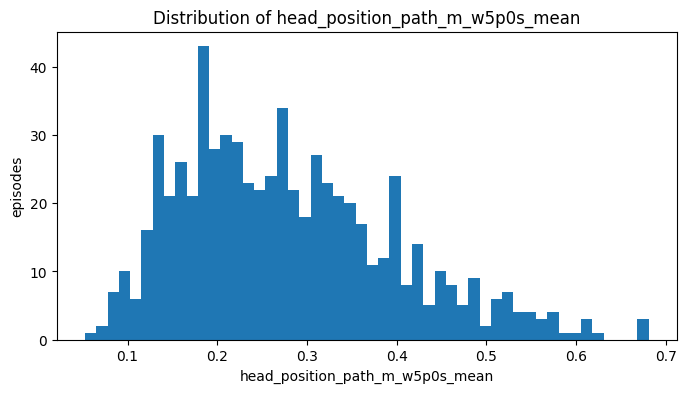

In [158]:
plot_distribution(subset, metric, bins=50)
plt.show()


In [161]:
grouped_metric_summary(subset, metric, group_col).tail(20)


,count,mean,median,max,p90,p95
operator_lab,,,,,,
liMUt-8vcABzgMW2 | rl2,34,0.351476,0.343139,0.573302,0.468958,0.490622
5ES9O8onNvOcpl1T | rl2,17,0.372333,0.341418,0.572859,0.525553,0.536783
cbb43DO-bmnqDXr5 | rl2,20,0.324176,0.314837,0.475332,0.447735,0.455949
ishxSoQCgN6NyjrQ | eth,75,0.320268,0.312654,0.671663,0.439112,0.496609
DGNH8qVgE-stb4Fq | rl2,14,0.316754,0.307852,0.556154,0.369732,0.439356
w06Lr-M7fxyxM1_2 | rl2,30,0.300174,0.306412,0.460888,0.426002,0.442212
F1_iXodjWgQOjiF3 | rl2,16,0.301495,0.300345,0.464892,0.402753,0.451374
VROAuSISD7m-3qs6 | rl2,42,0.311309,0.297371,0.588394,0.464199,0.519143
B9BG1frBKz-C2vUD | rl2,27,0.298999,0.294118,0.460784,0.397537,0.409207


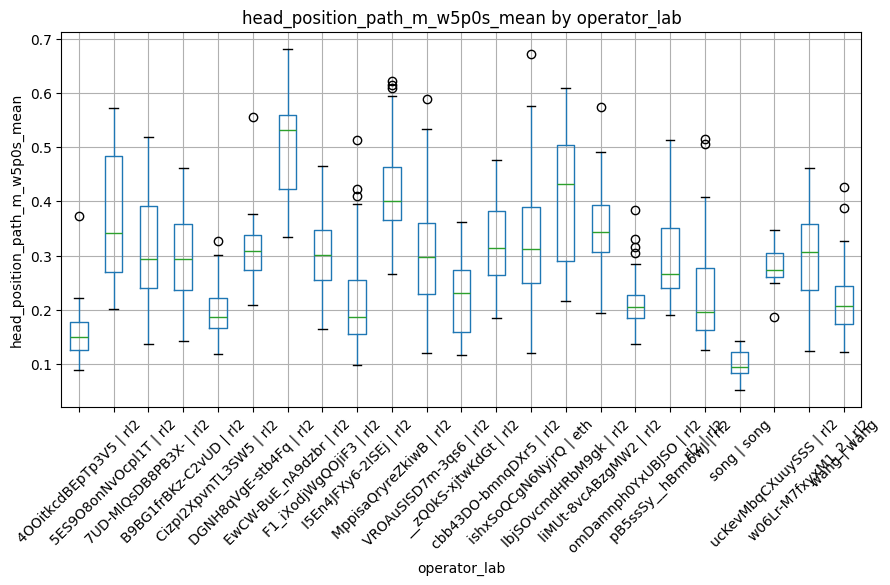

In [154]:
plot_group_boxplot(subset, metric, group_col, top_k=50)
plt.show()


## Threshold Sweep

Try a few cutoffs and see how many episodes survive.


In [ ]:
thresholds = np.linspace(
    pd.to_numeric(subset[metric], errors="coerce").quantile(0.50),
    pd.to_numeric(subset[metric], errors="coerce").quantile(0.99),
    10,
)
threshold_sweep(subset, metric, thresholds)


## Compare Two Metrics

Useful for deciding whether to threshold position and angle separately or via a combined score.


In [ ]:
metric_x = "head_position_path_m_w1p0s_mean"
metric_y = "head_angular_path_deg_w1p0s_mean"

working = subset[[metric_x, metric_y, "episode_hash", "operator", "lab"]].copy()
working[metric_x] = pd.to_numeric(working[metric_x], errors="coerce")
working[metric_y] = pd.to_numeric(working[metric_y], errors="coerce")
working = working.dropna(subset=[metric_x, metric_y])

pearson_corr = working[metric_x].corr(working[metric_y], method="pearson")
spearman_corr = working[metric_x].corr(working[metric_y], method="spearman")
display(pd.DataFrame([{"metric_x": metric_x, "metric_y": metric_y, "pearson": pearson_corr, "spearman": spearman_corr, "num_episodes": len(working)}]))

ax = working.plot.scatter(x=metric_x, y=metric_y, alpha=0.6, figsize=(7, 5))
fit = np.polyfit(working[metric_x], working[metric_y], deg=1)
x_line = np.linspace(working[metric_x].min(), working[metric_x].max(), 100)
ax.plot(x_line, fit[0] * x_line + fit[1], color="crimson", linewidth=2)
ax.set_title(f"{metric_y} vs {metric_x}\nPearson={pearson_corr:.3f}, Spearman={spearman_corr:.3f}")
plt.show()

working[[metric_x, metric_y, "episode_hash", "operator", "lab"]].sort_values(metric_x, ascending=False).head(10)


## Visualize One Episode

Pick an episode hash and render a short clip from the zarr using the same resolver pattern as the zarr visualization notebook.


In [109]:
from pathlib import Path

import cv2
import imageio_ffmpeg
import mediapy as mpy
import numpy as np
import zarr

mpy.set_ffmpeg(imageio_ffmpeg.get_ffmpeg_exe())

VIDEO_CACHE_ROOT = Path("/coc/flash7/scratch/egoverseS3ZarrDataset/")
VIDEO_EPISODE_HASH = "2025-09-24-16-24-49-000000"
VIDEO_SECONDS = 30
VIDEO_FPS = 30
VIDEO_START_SECONDS = 0
VIDEO_IMAGE_KEY = "images.front_1"


In [113]:
if VIDEO_EPISODE_HASH is None:
    raise ValueError("Set VIDEO_EPISODE_HASH to an episode hash before running this cell.")

episode_dir_candidates = [
    VIDEO_CACHE_ROOT / VIDEO_EPISODE_HASH,
    VIDEO_CACHE_ROOT / f"{VIDEO_EPISODE_HASH}.zarr",
]
episode_path = next((path for path in episode_dir_candidates if path.exists()), None)
if episode_path is None:
    raise FileNotFoundError(
        f"Could not find local zarr for episode {VIDEO_EPISODE_HASH} under {VIDEO_CACHE_ROOT}"
    )

store = zarr.open_group(str(episode_path), mode="r")
if VIDEO_IMAGE_KEY not in store:
    raise KeyError(
        f"{VIDEO_IMAGE_KEY!r} not found in {episode_path}. Available keys: {list(store.array_keys())}"
    )

image_arr = store[VIDEO_IMAGE_KEY]
num_frames = image_arr.shape[0]
start_idx = max(0, int(VIDEO_START_SECONDS * VIDEO_FPS))
end_idx = min(num_frames, start_idx + int(VIDEO_SECONDS * VIDEO_FPS))

def decode_frame(frame):
    frame_np = np.asarray(frame)
    if frame_np.ndim == 3:
        if frame_np.shape[0] in (1, 3) and frame_np.shape[-1] not in (1, 3):
            frame_np = np.moveaxis(frame_np, 0, -1)
        if frame_np.dtype != np.uint8:
            if np.issubdtype(frame_np.dtype, np.floating) and frame_np.max() <= 1.0:
                frame_np = (255 * frame_np).clip(0, 255).astype(np.uint8)
            else:
                frame_np = frame_np.clip(0, 255).astype(np.uint8)
        return frame_np

    frame_obj = frame
    while isinstance(frame_obj, np.ndarray) and frame_obj.dtype == object:
        frame_obj = frame_obj.item()
    decoded = cv2.imdecode(np.frombuffer(frame_obj, dtype=np.uint8), cv2.IMREAD_COLOR)

    if decoded is None:
        raise ValueError("Failed to decode image frame from stored bytes")
    return cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)

frames = [decode_frame(image_arr[idx]) for idx in range(start_idx, end_idx)]
print(f"Loaded {len(frames)} raw frames from {episode_path} using key {VIDEO_IMAGE_KEY}")
mpy.show_video(frames, fps=VIDEO_FPS)


ValueError: Failed to decode image frame from stored bytes

In [111]:
sample = image_arr[start_idx]
print(type(sample))
print(np.asarray(sample).shape, np.asarray(sample).dtype, np.asarray(sample).ndim)

<class 'numpy.ndarray'>
() object 0


In [112]:
sample

array(array(array(b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x05\x03\x04\x04\x04\x03\x05\x04\x04\x04\x05\x05\x05\x06\x07\x0c\x08\x07\x07\x07\x07\x0f\x0b\x0b\t\x0c\x11\x0f\x12\x12\x11\x0f\x11\x11\x13\x16\x1c\x17\x13\x14\x1a\x15\x11\x11\x18!\x18\x1a\x1d\x1d\x1f\x1f\x1f\x13\x17"$"\x1e$\x1c\x1e\x1f\x1e\xff\xdb\x00C\x01\x05\x05\x05\x07\x06\x07\x0e\x08\x08\x0e\x1e\x14\x11\x14\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\xff\xc0\x00\x11\x08\x01\xe0\x02\x80\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3b